In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data_path = "/home/miku/logger/data/witsensor/2025/07/20250701_witsensor.raw"

In [5]:
# データを読み込み（適切にセパレータとヘッダーを処理）
import re

# ファイルを読み込んで手動で処理
with open(data_path, 'r') as f:
    lines = f.readlines()

In [4]:
lines

['## Localtime  Unixtime  AccX  AccY  AccZ  AsX  AsY  AsZ  HX  HY  HZ  AngX  AngY  AngZ\n',
 '# 2025-07-01T13:51:30.994473+09:00  1751345490.994473  No data\n',
 '2025-07-01T13:51:31.995180+09:00  1751345491.995180  0.033000  0.008000  1.000000  0.000000  0.000000  0.000000  -22.997000  -0.494000  -2.444000  0.445000  -1.900000  -122.949000\n',
 '2025-07-01T13:51:32.995474+09:00  1751345492.995474  0.033000  0.008000  1.000000  0.000000  0.000000  0.000000  -22.984000  -0.507000  -2.431000  0.445000  -1.900000  -122.949000\n',
 '2025-07-01T13:51:33.995753+09:00  1751345493.995753  0.033000  0.008000  1.000000  0.000000  0.000000  0.000000  -23.023000  -0.533000  -2.431000  0.445000  -1.901000  -122.949000\n',
 '2025-07-01T13:51:34.996010+09:00  1751345494.996010  0.033000  0.008000  1.000000  0.000000  0.000000  0.000000  -23.023000  -0.520000  -2.444000  0.445000  -1.901000  -122.949000\n',
 '2025-07-01T13:51:35.998173+09:00  1751345495.998173  0.033000  0.008000  1.000000  0.000000  

In [3]:
# データを読み込み（適切にセパレータとヘッダーを処理）
import re

# ファイルを読み込んで手動で処理
with open(data_path, 'r') as f:
    lines = f.readlines()

# ヘッダー行を取得（1行目の##を除去）
header_line = lines[0].strip()
headers = re.split(r'\s{2,}', header_line.replace('## ', ''))
print("ヘッダー:", headers)

# データ行を処理（"No data"行をスキップ）
data_lines = []
for line in lines[1:]:
    line = line.strip()
    if not line or 'No data' in line:
        continue
    # 2つ以上の連続するスペースで分割
    data = re.split(r'\s{2,}', line)
    if len(data) == len(headers):
        data_lines.append(data)

# データフレームを作成
df = pd.DataFrame(data_lines, columns=headers)

# 数値カラムを適切な型に変換
numeric_cols = ['Unixtime', 'AccX', 'AccY', 'AccZ', 'AsX', 'AsY', 'AsZ', 'HX', 'HY', 'HZ', 'AngX', 'AngY', 'AngZ']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# データの確認
print("データの形状:", df.shape)
print("\nカラム名:")
print(df.columns.tolist())
print("\n最初の5行:")
print(df.head())

# 欠損値の確認
print("\n欠損値の数:")
print(df.isnull().sum())

ヘッダー: ['Localtime', 'Unixtime', 'AccX', 'AccY', 'AccZ', 'AsX', 'AsY', 'AsZ', 'HX', 'HY', 'HZ', 'AngX', 'AngY', 'AngZ']
データの形状: (129, 14)

カラム名:
['Localtime', 'Unixtime', 'AccX', 'AccY', 'AccZ', 'AsX', 'AsY', 'AsZ', 'HX', 'HY', 'HZ', 'AngX', 'AngY', 'AngZ']

最初の5行:
                          Localtime      Unixtime   AccX   AccY  AccZ  AsX  \
0  2025-07-01T13:51:31.995180+09:00  1.751345e+09  0.033  0.008   1.0  0.0   
1  2025-07-01T13:51:32.995474+09:00  1.751345e+09  0.033  0.008   1.0  0.0   
2  2025-07-01T13:51:33.995753+09:00  1.751345e+09  0.033  0.008   1.0  0.0   
3  2025-07-01T13:51:34.996010+09:00  1.751345e+09  0.033  0.008   1.0  0.0   
4  2025-07-01T13:51:35.998173+09:00  1.751345e+09  0.033  0.008   1.0  0.0   

   AsY  AsZ      HX     HY     HZ   AngX   AngY     AngZ  
0  0.0  0.0 -22.997 -0.494 -2.444  0.445 -1.900 -122.949  
1  0.0  0.0 -22.984 -0.507 -2.431  0.445 -1.900 -122.949  
2  0.0  0.0 -23.023 -0.533 -2.431  0.445 -1.901 -122.949  
3  0.0  0.0 -23.023 -0.520 -2.

In [ ]:
# データフレームの状況を確認
print("カラム名:", df.columns.tolist())
print("データフレームの形状:", df.shape)
print("\n最初の数行:")
print(df.head())

# カラム名を確認して修正（先頭の#や##を除去）
if df.columns[0].startswith('##'):
    df.columns = df.columns.str.replace('## ', '').str.replace('# ', '').str.strip()
    print("\n修正後のカラム名:", df.columns.tolist())

# 時刻データをdatetimeに変換
df['Localtime'] = pd.to_datetime(df['Localtime'])

# データの基本統計
print("\n角度データの統計:")
angle_cols = ['AngX', 'AngY', 'AngZ']
print(df[angle_cols].describe())

# 時系列プロット
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# AngX, AngY, AngZをそれぞれプロット
for i, col in enumerate(angle_cols):
    axes[i].plot(df['Localtime'], df[col], label=col, linewidth=1)
    axes[i].set_ylabel(f'{col} (degrees)')
    axes[i].grid(True)
    axes[i].legend()

axes[0].set_title('Angle Data Time Series')
axes[2].set_xlabel('Time')
plt.tight_layout()
plt.show()

カラム名: ['Localtime', 'Unixtime', 'AccX', 'AccY', 'AccZ', 'AsX', 'AsY', 'AsZ', 'HX', 'HY', 'HZ', 'AngX', 'AngY', 'AngZ']
データフレームの形状: (129, 14)

最初の数行:
                          Localtime      Unixtime   AccX   AccY  AccZ  AsX  \
0  2025-07-01T13:51:31.995180+09:00  1.751345e+09  0.033  0.008   1.0  0.0   
1  2025-07-01T13:51:32.995474+09:00  1.751345e+09  0.033  0.008   1.0  0.0   
2  2025-07-01T13:51:33.995753+09:00  1.751345e+09  0.033  0.008   1.0  0.0   
3  2025-07-01T13:51:34.996010+09:00  1.751345e+09  0.033  0.008   1.0  0.0   
4  2025-07-01T13:51:35.998173+09:00  1.751345e+09  0.033  0.008   1.0  0.0   

   AsY  AsZ      HX     HY     HZ   AngX   AngY     AngZ  
0  0.0  0.0 -22.997 -0.494 -2.444  0.445 -1.900 -122.949  
1  0.0  0.0 -22.984 -0.507 -2.431  0.445 -1.900 -122.949  
2  0.0  0.0 -23.023 -0.533 -2.431  0.445 -1.901 -122.949  
3  0.0  0.0 -23.023 -0.520 -2.444  0.445 -1.901 -122.949  
4  0.0  0.0 -23.010 -0.507 -2.418  0.445 -1.901 -122.949  

角度データの統計:
             AngX

NameError: name 'angle_cols' is not defined

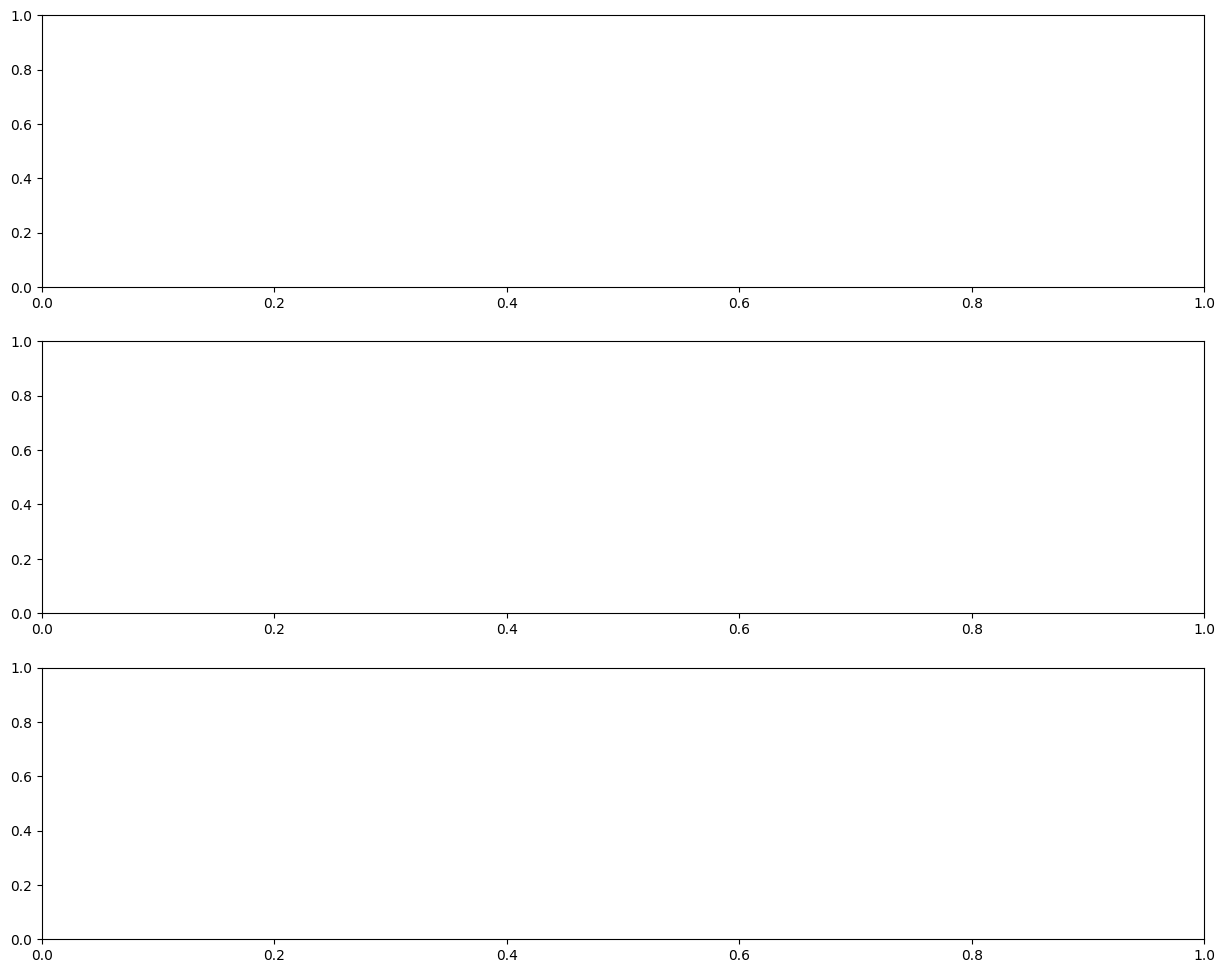

In [ ]:
# 数式当てはめと解析
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# 時間を数値に変換（開始時刻からの経過秒数）
time_numeric = (df['Unixtime'] - df['Unixtime'].iloc[0]).values.reshape(-1, 1)

# 各角度に対して線形回帰と多項式回帰を実行
results = {}

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for i, col in enumerate(angle_cols):
    y = df[col].values
    
    # 線形回帰
    linear_reg = LinearRegression()
    linear_reg.fit(time_numeric, y)
    y_pred_linear = linear_reg.predict(time_numeric)
    r2_linear = r2_score(y, y_pred_linear)
    
    # 2次多項式回帰
    poly_features = PolynomialFeatures(degree=2)
    time_poly = poly_features.fit_transform(time_numeric)
    poly_reg = LinearRegression()
    poly_reg.fit(time_poly, y)
    y_pred_poly = poly_reg.predict(time_poly)
    r2_poly = r2_score(y, y_pred_poly)
    
    # 結果を保存
    results[col] = {
        'linear_slope': linear_reg.coef_[0],
        'linear_intercept': linear_reg.intercept_,
        'linear_r2': r2_linear,
        'poly_r2': r2_poly
    }
    
    # プロット
    axes[i].scatter(time_numeric, y, alpha=0.5, s=1, label='Data', color='blue')
    axes[i].plot(time_numeric, y_pred_linear, 'r-', label=f'Linear (R²={r2_linear:.4f})', linewidth=2)
    axes[i].plot(time_numeric, y_pred_poly, 'g-', label=f'Polynomial (R²={r2_poly:.4f})', linewidth=2)
    axes[i].set_ylabel(f'{col} (degrees)')
    axes[i].set_title(f'{col} - Data Fitting')
    axes[i].legend()
    axes[i].grid(True)

axes[2].set_xlabel('Time since start (seconds)')
plt.tight_layout()
plt.show()

# 結果の表示
print("回帰分析結果:")
for col, result in results.items():
    print(f"\n{col}:")
    print(f"  線形回帰: y = {result['linear_slope']:.6f}x + {result['linear_intercept']:.6f}")
    print(f"  線形回帰 R²: {result['linear_r2']:.6f}")
    print(f"  多項式回帰 R²: {result['poly_r2']:.6f}")

In [ ]:
# 角度間の相関分析
correlation_matrix = df[angle_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation coefficient')
plt.xticks(range(len(angle_cols)), angle_cols)
plt.yticks(range(len(angle_cols)), angle_cols)
plt.title('Correlation Matrix of Angle Data')

# 相関係数を表示
for i in range(len(angle_cols)):
    for j in range(len(angle_cols)):
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.3f}', 
                ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

print("相関行列:")
print(correlation_matrix)

In [ ]:
# FFT解析による周波数成分分析
from scipy.fft import fft, fftfreq

# サンプリング周波数を推定（時間間隔の平均から）
time_diff = np.diff(df['Unixtime'])
sampling_rate = 1.0 / np.mean(time_diff)
print(f"推定サンプリング周波数: {sampling_rate:.2f} Hz")

# FFT解析
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

for i, col in enumerate(angle_cols):
    # 時系列データ
    y = df[col].values
    n = len(y)
    
    # FFT実行
    yf = fft(y)
    xf = fftfreq(n, 1/sampling_rate)
    
    # 正の周波数のみを取得
    positive_freq_idx = xf > 0
    frequencies = xf[positive_freq_idx]
    magnitude = np.abs(yf[positive_freq_idx])
    
    # 時系列プロット
    axes[i, 0].plot(time_numeric.flatten(), y)
    axes[i, 0].set_title(f'{col} - Time Domain')
    axes[i, 0].set_xlabel('Time (s)')
    axes[i, 0].set_ylabel('Angle (degrees)')
    axes[i, 0].grid(True)
    
    # 周波数スペクトラム
    axes[i, 1].loglog(frequencies, magnitude)
    axes[i, 1].set_title(f'{col} - Frequency Domain')
    axes[i, 1].set_xlabel('Frequency (Hz)')
    axes[i, 1].set_ylabel('Magnitude')
    axes[i, 1].grid(True)
    
    # 主要な周波数成分を特定
    peak_idx = np.argmax(magnitude)
    dominant_freq = frequencies[peak_idx]
    print(f"{col}: 主要周波数成分 = {dominant_freq:.4f} Hz, 周期 = {1/dominant_freq:.2f} s")

plt.tight_layout()
plt.show()